In [13]:
import scanpy as sc
import scrublet as scr
import scipy.io
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import gzip

sc.settings.set_figure_params(dpi=80)

In [14]:
# 输入目录
input_dir = '/project-whj/sis/2.tumbler/10.SC/1.expression_matrix/WMS510-DN/outs/filtered_cell_gene_matrix'
matrix_file = input_dir + '/matrix.mtx.gz'
features_file = input_dir + '/features.tsv.gz'
barcodes_file = input_dir + '/barcodes.tsv.gz'
out_dir = '/project-whj/sis/2.tumbler/10.SC/3.Seurat+scrublet'

# 读取压缩的矩阵文件
counts_matrix = scipy.io.mmread(matrix_file).T.tocsc()

# 读取 features.tsv.gz 文件
features_df = pd.read_csv(features_file, compression='gzip', delimiter='\t', header=None)
genes = np.array(features_df.iloc[:, 1].values)  # 提取第二列（基因名称）

# 读取 barcodes.tsv.gz 文件
barcodes_df = pd.read_csv(barcodes_file, compression='gzip', header=None, names=['barcode'])
barcodes = np.array(barcodes_df['barcode'].values)

# 打印矩阵形状
print('Counts matrix shape: {} rows, {} columns'.format(counts_matrix.shape[0], counts_matrix.shape[1]))

# 打印基因信息
print('Genes:', genes)

# 打印细胞条形码信息
print('Barcodes:', barcodes)

Counts matrix shape: 11840 rows, 22583 columns
Genes: ['LOC135579015' 'FHIP1B' 'CNGA4' ... 'KEH11_t21' 'ND6' 'KEH11_t22']
Barcodes: ['AACAACACGAAAGAGCTTGC' 'AACAACACGAATACTATGTT' 'AACAACACGAATATGTCCTT' ...
 'TTGTTCTTGGCGTGCCTTGA' 'TTGTTCTTGGGTTCTGATAC' 'TTGTTCTTGGTCTACTTAAC']


In [15]:

scrub = scr.Scrublet(counts_matrix, expected_doublet_rate=0.06)

Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.26
Detected doublet rate = 2.5%
Estimated detectable doublet fraction = 30.1%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 8.3%
Elapsed time: 34.3 seconds
Detected doublet rate = 2.5%
Estimated detectable doublet fraction = 30.1%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 8.3%


/project-whj/sis/software/anaconda3/envs/seurat_v5/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(<Figure size 640x320 with 3 Axes>,
 array([<Axes: title={'center': 'Predicted doublets'}, xlabel='UMAP 1', ylabel='UMAP 2'>,
        <Axes: title={'center': 'Doublet score'}, xlabel='UMAP 1', ylabel='UMAP 2'>],
       dtype=object))

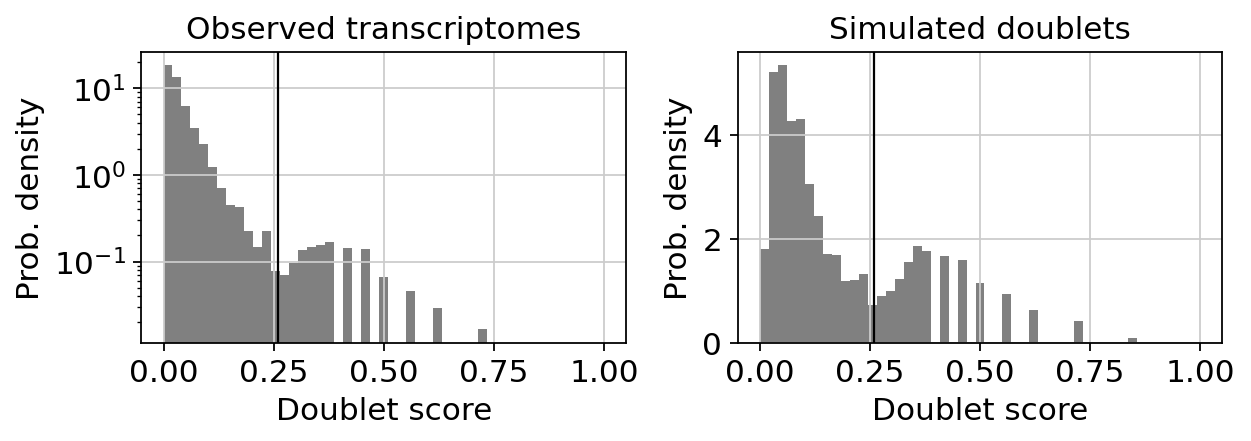

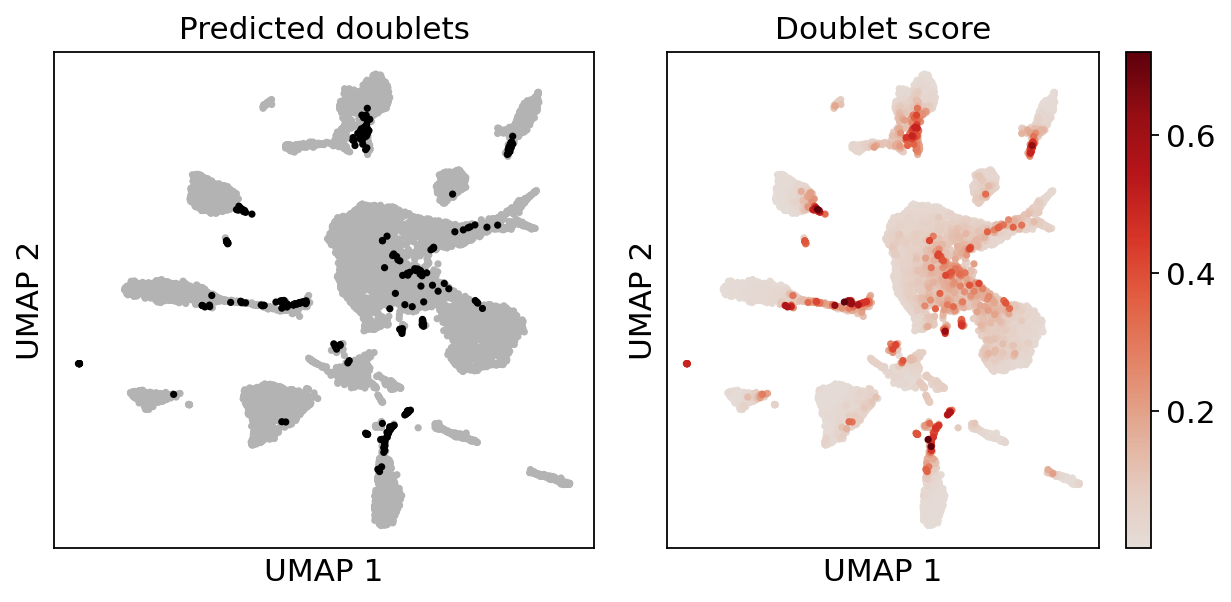

In [16]:
doublet_scores, predicted_doublets = scrub.scrub_doublets(min_counts=2, 
                                                          min_cells=3, 
                                                          min_gene_variability_pctl=85, 
                                                          n_prin_comps=30)
predicted_doublets = scrub.call_doublets(threshold=0.26)
scrub.plot_histogram()
#predicted_doublets = scrub.call_doublets(threshold=0.33)
#scrub.plot_histogram()
scrub.set_embedding('UMAP', scr.get_umap(scrub.manifold_obs_, 10, min_dist=0.3))
scrub.plot_embedding('UMAP', order_points=True)
# scrub.plot_embedding('tSNE', order_points=True);
# scrub.plot_embedding('FA', order_points=True);

In [17]:
# doublets占比
print (scrub.detected_doublet_rate_)

0.02491554054054054


In [18]:
barcodes_df['doublet_scores'] = doublet_scores
barcodes_df['predicted_doublets'] = predicted_doublets
barcodes_df.to_csv(out_dir + '/WMS510-DN-doublet.txt', index=False,header=True)
barcodes_df.head()

,barcode,doublet_scores,predicted_doublets
0,AACAACACGAAAGAGCTTGC,0.034805,False
1,AACAACACGAATACTATGTT,0.006250,False
2,AACAACACGAATATGTCCTT,0.095696,False
3,AACAACACGACAAGTAACCA,0.004413,False
4,AACAACACGACGGCGCTGCT,0.062653,False
